# Step 1 — Exploratory Data Analysis & Data Cleaning

In this notebook we load the raw Cape Town Airbnb `listings.csv`, explore its structure, clean price strings, handle missing values, and remove outliers to prepare a clean dataset for feature engineering.

In [14]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
df = pd.read_csv('../data/listings.csv')
print("Shape:", df.shape)
df.head()

Shape: (26877, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,15007,https://www.airbnb.com/rooms/15007,20250928034929,2025-09-28,city scrape,Blaauwberg House on the beach in Bloubergstrand,Welcome to our self-catering beach-front famil...,"Bloubergstrand is a lovely, cosy suburb near C...",https://a0.muscache.com/pictures/3b654aa4-248e...,59072,...,4.94,4.94,4.85,NaN,f,1,1,0,0,0.33
1,15068,https://www.airbnb.com/rooms/15068,20250928034929,2025-09-28,city scrape,Grande Bay,Modern spacious apartment. Three bedrooms two...,Close to Eden on The Bay and lots of restauran...,https://a0.muscache.com/pictures/a09b3f0d-d43b...,59318,...,NaN,NaN,NaN,NaN,f,5,5,0,0,NaN
2,15077,https://www.airbnb.com/rooms/15077,20250928034929,2025-09-28,city scrape,Relaxed beach living in style,Our Superior Rooms (approx. 25 m²) are located...,It is probably the best hub in order to explor...,https://a0.muscache.com/pictures/4a8fceaa-655e...,59342,...,4.71,4.86,5.00,NaN,f,6,1,5,0,0.05
3,15199,https://www.airbnb.com/rooms/15199,20250928034929,2025-09-29,city scrape,Self catering apartment,NaN,NaN,https://a0.muscache.com/pictures/142776/5b6c9e...,59694,...,5.00,5.00,4.00,NaN,f,1,1,0,0,0.01
4,15354,https://www.airbnb.com/rooms/15354,20250928034929,2025-09-29,previous scrape,"Aurora Self Catering Units, Durbanville, Cape ...",Durbanville is centrally located for daytrips ...,Durbanville is a really lovely village half an...,https://a0.muscache.com/pictures/113126/f1bb90...,60196,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN


In [16]:
price_cols = ['price']
print(df[price_cols].dtypes)

price    str
dtype: object


In [17]:
from src.preprocess import clean_price
df['price_clean'] = clean_price(df['price'])


In [18]:
from src.preprocess import filter_price_range
df = filter_price_range(df, low=100, high=10000)
print("After removing price outliers (between 100 and 10000 ZAR):", df.shape)


After removing price outliers: (6156, 80)


In [19]:
important_cols = ['bedrooms', 'bathrooms_text', 'accommodates', 'room_type', 
                  'neighbourhood_cleansed', 'availability_365', 'host_is_superhost', 
                  'host_identity_verified', 'price_clean']
missing = df[important_cols].isnull().sum()
print(missing[missing > 0])

bedrooms                   17
bathrooms_text             33
host_is_superhost         170
host_identity_verified      4
dtype: int64


In [20]:
from src.preprocess import extract_bathrooms
df['bathrooms'] = extract_bathrooms(df['bathrooms_text'])


In [21]:
critical = ['bedrooms', 'bathrooms', 'accommodates', 'room_type', 'neighbourhood_cleansed']
df_clean = df.dropna(subset=critical)
print(f"Remaining rows after dropping NA: {len(df_clean)}")

Remaining rows after dropping NA: 4480


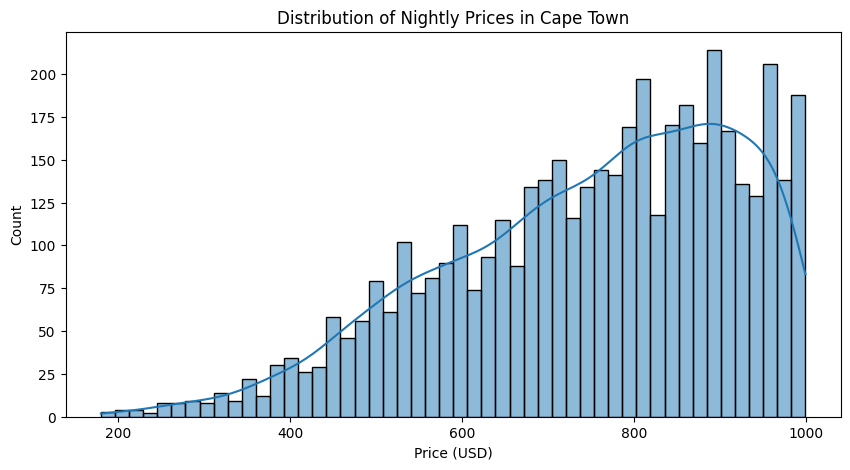

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean['price_clean'], bins=50, kde=True)
plt.title('Distribution of Nightly Prices in Cape Town')
plt.xlabel('Price (USD)')
plt.show()

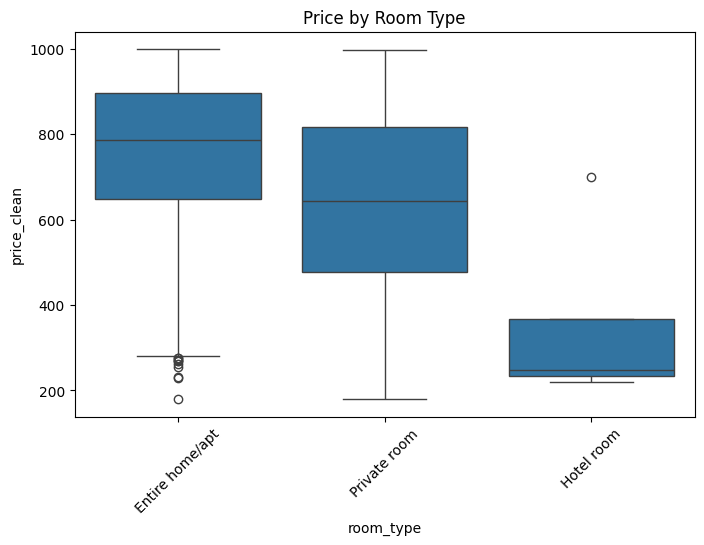

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price_clean', data=df_clean)
plt.xticks(rotation=45)
plt.title('Price by Room Type')
plt.show()

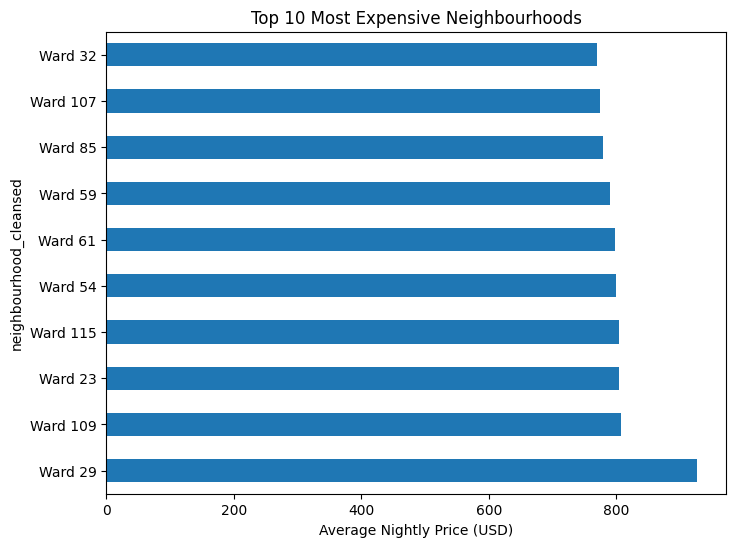

In [24]:
neigh_price = df_clean.groupby('neighbourhood_cleansed')['price_clean'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,6))
neigh_price.plot(kind='barh')
plt.title('Top 10 Most Expensive Neighbourhoods')
plt.xlabel('Average Nightly Price (USD)')
plt.show()

In [25]:
df_clean.to_csv('../data/listings_cleaned.csv', index=False)
print("Cleaned data saved to ../data/listings_cleaned.csv")
print("Columns saved:", df_clean.columns.tolist())

Cleaned data saved to ../data/listings_cleaned.csv
Columns saved: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', '